# 1.0 SNR — 누설 지점(POI) 찾기 · Normal ∥ Masked

## 이 노트북이 답하는 질문

파형은 수만 샘플이다. 그중 **어느 시점이 비밀과 관련된 정보를 흘리는가?**

`scalib.metrics.SNR` 은 시점마다 **신호대잡음비**를 계산해 그 질문에 답한다.
여기서 얻은 지점(POI, Point Of Interest)은 이후 모든 노트북의 출발점이다 —
CPA 는 그 근처에서 상관 봉우리를 찾고, 프로파일링은 그 지점만 골라 모델을 세운다.

그리고 이 노트북은 같은 질문을 **두 타겟에 나란히** 던진다.

| | Normal | Masked |
|---|---|---|
| 라이브러리 | `tiny-AES-c` (비마스킹) | `masked-aes-c` (1차 불리언 마스킹) |
| 입력 | `/explore` 5,000장 (랜덤 키·랜덤 평문) | 같음 |
| 하드웨어 | 불필요 | 불필요 |

**핵심 질문:** 마스킹이 걸리면 1라운드 SBox 출력의 SNR 이 정말 잡음 바닥까지 내려가는가?

## SNR 이 무엇인가

파형의 한 시점 $j$ 를 보자. 중간값 $v$(예: SBox 출력 한 바이트)가 값마다 다른 전력을
쓴다면, $v$ 로 트레이스를 묶었을 때 **묶음마다 평균이 달라진다.**

$$
\mathrm{SNR}_j = \frac{\mathrm{Var}_v\left[\ \mathbb{E}[\ l_j \mid v\ ]\ \right]}
                      {\mathbb{E}_v\left[\ \mathrm{Var}[\ l_j \mid v\ ]\ \right]}
$$

- 분자 = **신호**: 클래스별 평균이 서로 얼마나 벌어져 있는가
- 분모 = **잡음**: 같은 클래스 안에서 값이 얼마나 흩어져 있는가

SNR 이 크면 그 시점은 중간값에 대해 말이 많다는 뜻이다. 0 에 가까우면 무관하다.

> SNR 은 **누설의 위치와 세기**를 알려줄 뿐 키를 복구하지 않는다.
> 키 복구는 3.0 CPA 이후의 노트북이 한다.

## 진행 순서

| 단계 | 내용 |
|:----:|------|
| 1–2 | 데이터 적재, 파형 한 장 |
| 3 | **암호화 구간 경계 찾기** — 비교를 어디서 해야 하는가 |
| 4 | 공격자 라벨 만들기 — 무엇을 "중간값" 으로 볼 것인가 |
| 5 | `SNR` API 규약과 실행 (Normal ∥ Masked ∥ 비교) |
| 6 | 대조군 — 잡음 바닥 |
| 7 | 클래스 정의 바꿔 보기 (값 256 vs 해밍 가중치 9) |
| 8 | 트레이스 수에 따른 안정성 |
| 9 | POI 저장 |
| 10 | **연구자 관점** — 마스킹 난수를 안다면 |
| 11 | 마스크 품질 점검 |

---
## 1. 준비

경로·라벨·AES 상수의 정본은 `scalib_common.py` 하나다. 노트북마다 복사하면 값을
고칠 곳이 열 군데가 되기 때문에 여기서는 import 만 한다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, HW, AES_BLOCK, sbox_out,
    load_group, load_poi, group_len, dataset_summary, require_target,
)

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

[Normal] Normal AES (tiny-AES-c)
  path         /workspace/[extra] SCALib/traces/scalib_dataset_tiny-AES-c.h5
  schema_version         1.0
  acquisition_start      2026-08-07T00:34:27
  iut_algorithm          AES-128-ECB
  iut_implementation     tiny-AES-c
  iut_countermeasure     none
  target_name            CW308_STM32F3
  target_clock_hz        7384494.0
  channel_type           power
  channel_probe          CW308 SHUNTL (내장 션트), Husky Measure 입력
  sample_rate_hz         29537976.0
  sample_resolution_bits 12
  samples_per_trace      33172
  sample_dtype           int16
  sample_scale           32768.0
  trigger_semantics      MY_AES_ECB 전체 — AES_init_ctx(KeyExpansion) + AES_ECB_encrypt
  alignment              none
  스키마 준수                 예
  Subset
    /attack     [attack                  ]  10000 장 x 33172 샘플   키=fixed 평문=random
    /explore    [exploration             ]   5000 장 x 33172 샘플   키=random 평문=random
    /profiling  [profiling               ] 100000 

---
## 2. 데이터 적재 · 파형 한 장

`/explore` 는 키와 평문이 **둘 다 랜덤**이다. 그래서 1라운드 SBox 출력이 256 값을
고루 돌며, 클래스별 표본이 균형 있게 모인다 — SNR 추정에 필요한 조건이다.

두 타겟의 파형 길이가 다르다는 점에 주의한다. 길이는 상수로 박은 값이 아니라 수집 때
`scope.adc.trig_count` 로 실측한 것이고, 마스킹 구현이 연산을 더 많이 하므로 더 길다.

[Normal] t(5000, 33172)  ns=None  cipher=None


[Masked] t(5000, 55184)  ns=None  cipher=None
        mask(5000, 10) — 연구용 마스크 (10절에서만 쓴다)


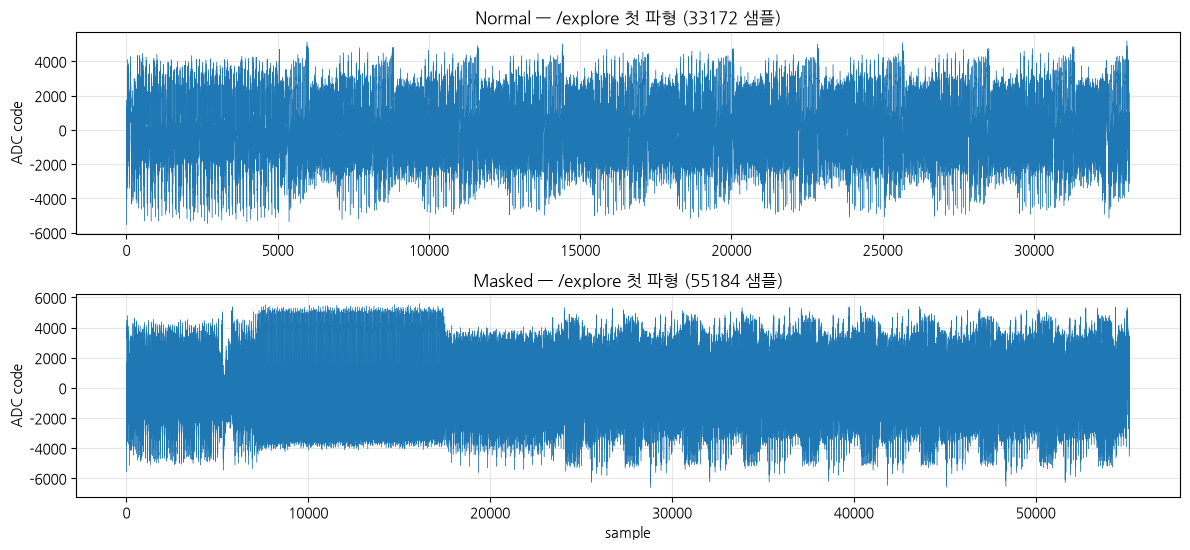

In [2]:
data = {}
for tid in TARGET_IDS:
    if not require_target(tid)["dataset"].is_file():
        print("[%s] 데이터셋 없음 — skip" % TARGETS[tid]["short"])
        continue
    d = load_group("explore", target=tid)
    data[tid] = d
    print("[%s] t%s  ns=%s  cipher=%s" % (
        TARGETS[tid]["short"], d["t"].shape,
        d["attrs"].get("ns"), d["attrs"].get("cipher")))
    if d["m"] is not None:
        print("        mask%s — 연구용 마스크 (10절에서만 쓴다)" % (d["m"].shape,))

if not data:
    raise FileNotFoundError("분석할 데이터셋이 없다. 0.0 / 0.1 수집 노트북을 먼저 실행한다.")

fig, axes = plt.subplots(len(data), 1, figsize=(12, 2.8 * len(data)))
if len(data) == 1:
    axes = [axes]
for ax, tid in zip(axes, data):
    ax.plot(data[tid]["t"][0], lw=0.3)
    ax.set_title("%s — /explore 첫 파형 (%d 샘플)"
                 % (TARGETS[tid]["short"], data[tid]["t"].shape[1]))
    ax.set_ylabel("ADC code"); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("sample")
fig.tight_layout(); plt.show()

---
## 3. 암호화 구간 경계 — 비교를 어디서 해야 하는가

여기서 한 가지를 먼저 정리해야 한다. **두 타겟의 파형은 앞부분이 서로 같은 코드다.**

`simpleserial_*/my_crypt.c` 의 `MY_AES_ECB` 는 트리거 구간 안에서

```c
AES_init_ctx(&ctx, input_k);   /* ← KeyExpansion. 여기가 문제다 */
AES_ECB_encrypt(&ctx, output); /* ← Cipher / CipherMasked */
```

를 부른다. 그런데 `masked-aes-c` 의 `KeyExpansion` 은 **벤더 원본 그대로 비마스킹**이다
(`masked-aes-c/aes.c`). 마스킹은 `CipherMasked` 안에서만 적용된다.

즉 파형 앞부분(키 스케줄)은 Normal 이든 Masked 든 **똑같이 무방비**다.
이 구간을 포함해 전 구간으로 두 타겟을 비교하면, 마스킹이 실제로 하는 일이 이
공통 누설에 가려진다. 실제로 2.0 TVLA 를 전 구간으로 재면 두 타겟이 거의 같은
$|t|$ 를 내는데, 그것은 "마스킹이 안 통한다" 가 아니라 "키 스케줄을 보고 있다" 는 뜻이다.

### 경계를 어떻게 정하는가

상수를 박지 않는다. **평문 의존 누설이 시작되는 지점**을 데이터에서 찾는다.

- 키 스케줄은 키만 가지고 하는 계산이라 **평문과 무관**하다 → 평문 라벨 SNR 이 바닥이다.
- 암호화가 시작되면 평문이 상태에 들어가므로 평문 라벨 SNR 이 솟는다.

이 정의는 구현·플랫폼·컴파일러에 의존하지 않는다. 함께 **키 라벨 SNR** 도 재서
"키 누설이 어디까지 이어지는가" 를 본다 — 마스킹의 효과가 여기서 드러난다.

산출한 `enc_start` 는 9절에서 POI 와 함께 저장되어 2.0–6.0 이 그대로 쓴다.

In [3]:
from scalib.metrics import SNR


def snr_of(traces, labels, nc=256):
    """(n, ns) int16 파형과 (n, nv) uint16 라벨로 (nv, ns) SNR 을 구한다."""
    s = SNR(nc=nc)
    s.fit_u(np.ascontiguousarray(traces), np.ascontiguousarray(labels, dtype=np.uint16))
    return s.get_snr()


rng = np.random.RandomState(0)
enc_start = {}
seg_snr = {}

for tid, d in data.items():
    t = d["t"]
    n, ns = t.shape
    snr_p = snr_of(t, d["p"]).max(axis=0)                      # 평문 의존
    snr_k = snr_of(t, d["k"]).max(axis=0)                      # 키 의존
    snr_0 = snr_of(t, rng.randint(0, 256, (n, 16))).max(axis=0)  # 무관 (바닥)
    seg_snr[tid] = (snr_p, snr_k, snr_0)

    # 바닥의 99.9 백분위를 기준으로 삼는다. 1.5배를 넘는 첫 샘플이 암호화 시작.
    floor = float(np.percentile(snr_0, 99.9))
    thr = floor * 1.5
    over_p = np.flatnonzero(snr_p > thr)
    over_k = np.flatnonzero(snr_k > thr)
    if over_p.size == 0:
        raise RuntimeError("[%s] 평문 의존 누설을 찾지 못했다 — 라벨·데이터를 확인한다."
                           % TARGETS[tid]["short"])
    enc_start[tid] = int(over_p[0])
    print("[%s] 바닥(99.9%%)=%.4f  임계=%.4f" % (TARGETS[tid]["short"], floor, thr))
    print("     평문 의존 누설  첫 샘플 %6d   (초과 %d개)" % (over_p[0], over_p.size))
    print("     키   의존 누설  %6d ~ %6d   (초과 %d개)"
          % (over_k[0], over_k[-1], over_k.size))
    print("     → enc_start = %d   암호화 구간 %d ~ %d (%.1f%%)"
          % (enc_start[tid], enc_start[tid], ns,
             100 * (ns - enc_start[tid]) / ns))
    print()

if len(enc_start) == 2:
    a, b = [enc_start[t] for t in TARGET_IDS]
    print("[비교] 두 타겟의 암호화 시작점 차이 = %d 샘플 (adc_mul=4 이므로 약 %.1f 타겟 사이클)"
          % (abs(a - b), abs(a - b) / 4))
    print("       거의 같다는 것이 곧 '앞부분은 동일한 비마스킹 KeyExpansion' 이라는 증거다.")

[Normal] 바닥(99.9%)=0.0741  임계=0.1111
     평문 의존 누설  첫 샘플   5093   (초과 87개)
     키   의존 누설     145 ~   8633   (초과 337개)
     → enc_start = 5093   암호화 구간 5093 ~ 33172 (84.6%)



[Masked] 바닥(99.9%)=0.0746  임계=0.1119
     평문 의존 누설  첫 샘플   5089   (초과 133개)
     키   의존 누설     141 ~  27194   (초과 404개)
     → enc_start = 5089   암호화 구간 5089 ~ 55184 (90.8%)

[비교] 두 타겟의 암호화 시작점 차이 = 4 샘플 (adc_mul=4 이므로 약 1.0 타겟 사이클)
       거의 같다는 것이 곧 '앞부분은 동일한 비마스킹 KeyExpansion' 이라는 증거다.


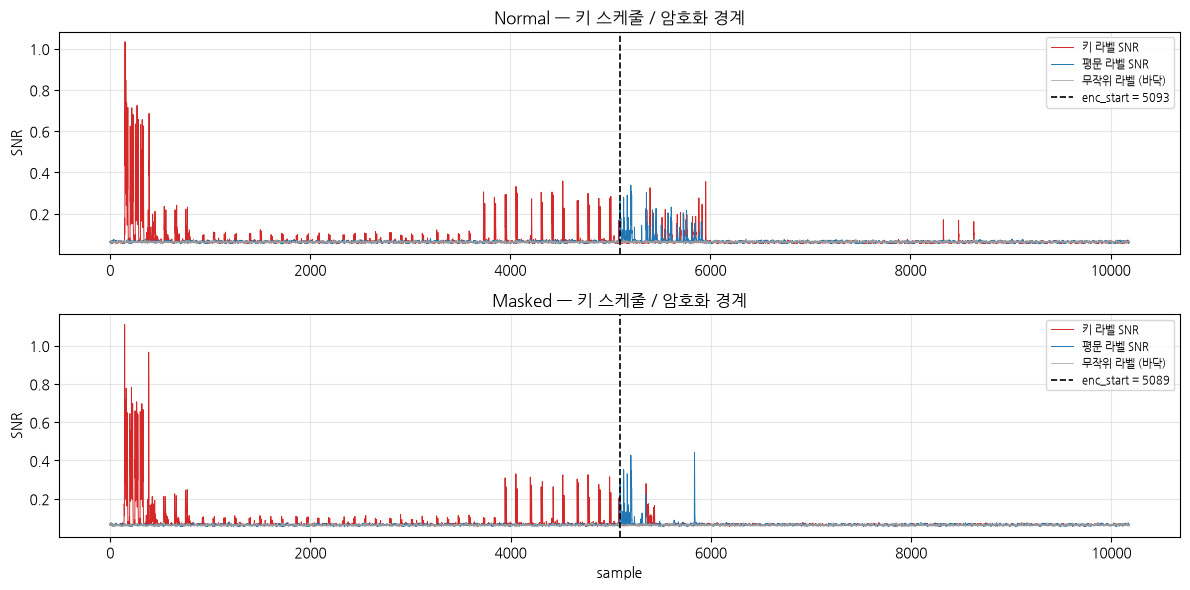

왼쪽(키만 새는 구간) = KeyExpansion. 점선 이후가 실제 암호화다.
Masked 에서 키 라벨 SNR 이 점선 근처에서 빨리 사그라들면,
마스킹이 암호화 구간의 키 의존 누설을 실제로 눌렀다는 뜻이다.


In [4]:
fig, axes = plt.subplots(len(data), 1, figsize=(12, 3.0 * len(data)))
if len(data) == 1:
    axes = [axes]
for ax, tid in zip(axes, data):
    snr_p, snr_k, snr_0 = seg_snr[tid]
    lim = enc_start[tid] * 2   # 경계 부근만 확대
    x = np.arange(lim)
    ax.plot(x, snr_k[:lim], lw=0.7, label="키 라벨 SNR", color="C3")
    ax.plot(x, snr_p[:lim], lw=0.7, label="평문 라벨 SNR", color="C0")
    ax.plot(x, snr_0[:lim], lw=0.5, label="무작위 라벨 (바닥)", color="0.6")
    ax.axvline(enc_start[tid], color="k", ls="--", lw=1.2,
               label="enc_start = %d" % enc_start[tid])
    ax.set_title("%s — 키 스케줄 / 암호화 경계" % TARGETS[tid]["short"])
    ax.set_ylabel("SNR"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("sample")
fig.tight_layout(); plt.show()

print("왼쪽(키만 새는 구간) = KeyExpansion. 점선 이후가 실제 암호화다.")
print("Masked 에서 키 라벨 SNR 이 점선 근처에서 빨리 사그라들면,")
print("마스킹이 암호화 구간의 키 의존 누설을 실제로 눌렀다는 뜻이다.")

---
## 4. 공격자 라벨 만들기

SNR 은 "무엇에 대한" 신호대잡음비인지를 **라벨**로 지정받는다. 라벨을 무엇으로 두느냐가
곧 "어떤 중간값의 누설을 찾는가" 이다.

여기서는 **1라운드 SBox 출력**을 본다.

$$ y_i = \mathrm{SBOX}[\ p_i \oplus k_i\ ] \qquad (i = 0..15) $$

이 값을 고르는 이유는 두 가지다.

1. **비선형**이다. XOR 만 거친 값($p \oplus k$)은 키 추측이 틀려도 누설이 비슷하게 보여
   구분이 잘 안 된다. S-box 를 통과하면 한 비트만 틀려도 출력이 크게 달라진다.
2. **바이트 단위로 분리**된다. 평문 한 바이트와 키 한 바이트에만 의존하므로 키를 16조각으로
   나누어 공략할 수 있다.

**두 타겟에 같은 라벨을 쓴다.** 이것이 공격자의 관점이다 — 공격자는 타겟이 마스킹을
하는지 알더라도 그 난수 값은 모르므로, 마스킹되지 않은 값을 겨눌 수밖에 없다.
Masked 에서 이 라벨의 SNR 이 바닥으로 떨어진다면 그것이 곧 마스킹이 동작한다는 증거다.

`sbox_out()` 은 `scalib_common.py` 에 정의되어 있다.

In [5]:
labels = {}
for tid, d in data.items():
    y = sbox_out(d["p"], d["k"])          # (n, 16)
    labels[tid] = y.astype(np.uint16)
    print("[%s] labels %s   바이트0 의 서로 다른 값 %d/256"
          % (TARGETS[tid]["short"], y.shape, len(np.unique(y[:, 0]))))

[Normal] labels (5000, 16)   바이트0 의 서로 다른 값 256/256
[Masked] labels (5000, 16)   바이트0 의 서로 다른 값 256/256


---
## 5. `SNR` API 와 실행

| 단계 | 코드 | 역할 |
|:----:|------|------|
| 생성 | `snr = SNR(nc=256)` | 클래스 개수를 정한다 |
| 누적 | `snr.fit_u(traces, x)` | 여러 번 호출해 누적할 수 있다 (대용량용) |
| 결과 | `snr.get_snr()` | shape `(nv, ns)` 의 SNR 배열 |

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 파형(`traces`)은 어디서나 `(n, ns)` `int16` 이다.

`nv` 는 **동시에 볼 변수의 개수**다. 여기서는 16바이트를 한 번에 넣어 `(16, ns)` 를 받는다.
바이트마다 따로 돌리는 것보다 훨씬 빠르다 — 파형을 한 번만 훑기 때문이다.

=== Normal ===
  암호화 구간 최대 SNR : 1.1390
  바이트0  POI=  6045  SNR=1.1016
  POI 범위 : 6045 ~ 6897


=== Masked ===
  암호화 구간 최대 SNR : 0.0822
  바이트0  POI= 32789  SNR=0.0775
  POI 범위 : 5337 ~ 52165


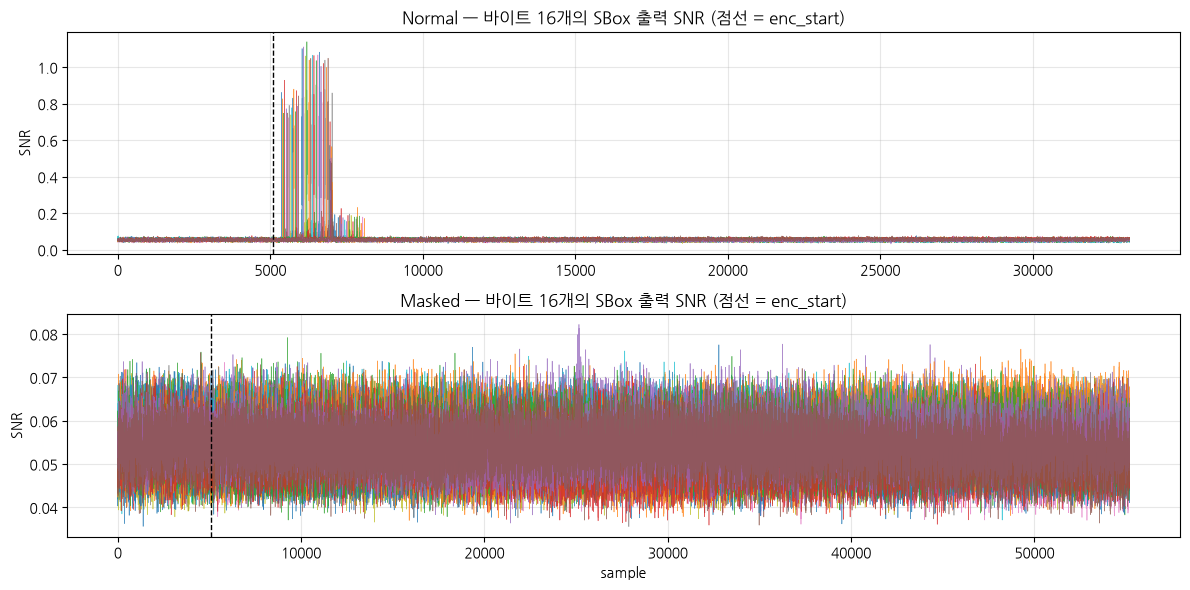

In [6]:
snr_map = {}
poi_map = {}

for tid, d in data.items():
    snr_val = snr_of(d["t"], labels[tid])       # (16, ns)
    snr_map[tid] = snr_val

    # POI 는 암호화 구간에서만 고른다 (3절). 키 스케줄 구간의 봉우리는
    # 1라운드 SBox 와 무관한 허위 POI 이고, 실제로 그런 POI 를 쓰면 공격이 실패한다.
    lo = enc_start[tid]
    poi = lo + snr_val[:, lo:].argmax(axis=1)
    poi_map[tid] = poi
    peak = snr_val[np.arange(16), poi]

    print("=== %s ===" % TARGETS[tid]["short"])
    print("  암호화 구간 최대 SNR : %.4f" % peak.max())
    print("  바이트0  POI=%6d  SNR=%.4f" % (poi[0], peak[0]))
    print("  POI 범위 : %d ~ %d" % (poi.min(), poi.max()))

fig, axes = plt.subplots(len(data), 1, figsize=(12, 3.0 * len(data)))
if len(data) == 1:
    axes = [axes]
for ax, tid in zip(axes, data):
    for i in range(16):
        ax.plot(snr_map[tid][i], lw=0.45, alpha=0.75)
    ax.axvline(enc_start[tid], color="k", ls="--", lw=1.0)
    ax.set_title("%s — 바이트 16개의 SBox 출력 SNR (점선 = enc_start)"
                 % TARGETS[tid]["short"])
    ax.set_ylabel("SNR"); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("sample")
fig.tight_layout(); plt.show()

---
## 6. 대조군 — 잡음 바닥

SNR 값이 "크다" 는 것은 상대적이다. 기준을 잡기 위해 **무작위 라벨**로 같은 계산을 돌린다.
중간값과 무관한 라벨이므로 신호가 없어야 하고, 남는 것은 추정 오차뿐이다.
이것이 이 데이터·이 장수에서의 **잡음 바닥**이다.

Masked 를 판정할 때 이 바닥이 결정적이다. "Masked 의 SNR 이 작다" 만으로는 부족하고,
**바닥과 구분되지 않는다**는 것을 보여야 마스킹이 동작한다고 말할 수 있다.

In [7]:
print("타겟      실제 라벨 max   무작위 라벨 max      비율   판정")
verdict = {}
for tid, d in data.items():
    n = d["t"].shape[0]
    null_max = float(snr_of(d["t"], rng.randint(0, 256, (n, 1))).max())
    lo = enc_start[tid]
    real_max = float(snr_map[tid][:, lo:].max())
    ratio = real_max / null_max if null_max > 0 else float("inf")
    verdict[tid] = (real_max, null_max, ratio)
    print("%-8s  %13.4f  %16.4f  %7.2f   %s" % (
        TARGETS[tid]["short"], real_max, null_max, ratio,
        "누설 있음" if ratio > 2 else "바닥과 구분 안 됨"))

print()
print("[비교] 암호화 구간에서 1라운드 SBox 라벨이 보이는가")
for tid in verdict:
    real_max, null_max, ratio = verdict[tid]
    print("  %-8s SNR %.4f = 바닥의 %.2f배" % (TARGETS[tid]["short"], real_max, ratio))
if len(verdict) == 2:
    r_normal = verdict["tiny-AES-c"][2]
    r_masked = verdict["masked-aes-c"][2]
    print()
    print("  Normal 은 바닥의 %.1f배 — 1라운드 SBox 가 그대로 보인다." % r_normal)
    if r_masked < 2:
        print("  Masked 는 바닥의 %.2f배 — 사실상 구분되지 않는다." % r_masked)
        print("  → 공격자가 아는 라벨(SBOX[p^k])로는 1차 누설이 잡히지 않는다. 마스킹이 동작한다.")
    else:
        print("  Masked 도 바닥의 %.2f배로 남아 있다 — 10절의 연구자 관점과 함께 원인을 본다."
              % r_masked)

타겟      실제 라벨 max   무작위 라벨 max      비율   판정
Normal           1.1390            0.0764    14.91   누설 있음
Masked           0.0822            0.0710     1.16   바닥과 구분 안 됨

[비교] 암호화 구간에서 1라운드 SBox 라벨이 보이는가
  Normal   SNR 1.1390 = 바닥의 14.91배
  Masked   SNR 0.0822 = 바닥의 1.16배

  Normal 은 바닥의 14.9배 — 1라운드 SBox 가 그대로 보인다.
  Masked 는 바닥의 1.16배 — 사실상 구분되지 않는다.
  → 공격자가 아는 라벨(SBOX[p^k])로는 1차 누설이 잡히지 않는다. 마스킹이 동작한다.


---
## 7. 클래스 정의를 바꿔 보기

라벨을 무엇으로 두느냐에 따라 SNR 이 달라진다. 자주 쓰는 두 가지를 비교한다.

| 라벨 | 클래스 수 | 뜻 |
|------|:--------:|-----|
| SBox 출력 값 | 256 | 값 자체가 다르면 다른 클래스 |
| SBox 출력의 **해밍 가중치** | 9 | 1비트 개수만 본다 (0~8) |

해밍 가중치는 클래스가 9개뿐이라 **클래스당 표본이 훨씬 많아** 적은 트레이스로도 안정적이다.
대신 값이 달라도 비트 수가 같으면 한 클래스로 묶여 정보를 잃는다.
어느 쪽이 큰지는 타겟의 실제 누설 형태에 달려 있다.

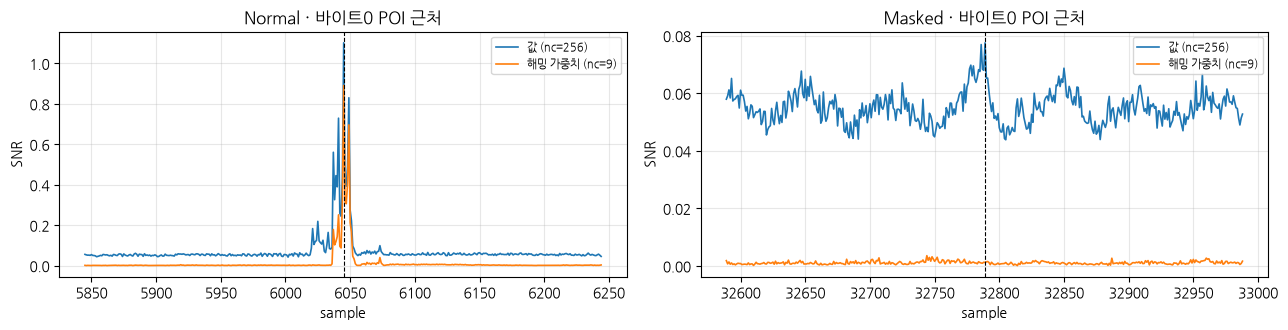

In [8]:
fig, axes = plt.subplots(1, len(data), figsize=(6.5 * len(data), 3.4))
if len(data) == 1:
    axes = [axes]
for ax, tid in zip(axes, data):
    d = data[tid]
    hw_val = snr_of(d["t"], HW[labels[tid]], nc=9)
    poi0 = int(poi_map[tid][0])
    lo, hi = max(0, poi0 - 200), min(d["t"].shape[1], poi0 + 200)
    ax.plot(range(lo, hi), snr_map[tid][0, lo:hi], lw=1.2, label="값 (nc=256)")
    ax.plot(range(lo, hi), hw_val[0, lo:hi], lw=1.2, label="해밍 가중치 (nc=9)")
    ax.axvline(poi0, color="k", ls="--", lw=0.8)
    ax.set_title("%s · 바이트0 POI 근처" % TARGETS[tid]["short"])
    ax.set_xlabel("sample"); ax.set_ylabel("SNR")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 8. 트레이스 수에 따른 안정성

SNR 은 **추정값**이다. 트레이스가 적으면 신호가 없어도 우연히 값이 커진다
(클래스당 표본이 적어 평균이 흔들리기 때문). 얼마나 모아야 믿을 만한지 본다.

여기서 무작위 라벨 값이 장수와 함께 줄어드는 것이 핵심이다 — 그것이 "바닥" 이
표본 수의 함수라는 뜻이고, **Masked 의 SNR 이 그 바닥을 따라 내려간다면**
그 값은 신호가 아니라 추정 오차라는 근거가 된다.

In [9]:
subsets = [250, 500, 1000, 2000]
print("타겟      장수    실제 max   무작위 max     비율")
for tid, d in data.items():
    t = d["t"]
    y = labels[tid][:, :1]
    n = t.shape[0]
    for m in subsets + [n]:
        m = min(m, n)
        real = float(snr_of(t[:m], y[:m]).max())
        null = float(snr_of(t[:m], rng.randint(0, 256, (m, 1))).max())
        print("%-8s %6d  %10.4f  %11.4f  %7.2f"
              % (TARGETS[tid]["short"], m, real, null, real / null))
    print()

타겟      장수    실제 max   무작위 max     비율
Normal      250      5.1354       3.6069     1.42
Normal      500      2.9567       1.4087     2.10
Normal     1000      1.7393       0.4789     3.63
Normal     2000      1.3097       0.1961     6.68


Normal     5000      1.1016       0.0716    15.38

Masked      250      3.3403       4.6739     0.71
Masked      500      1.3709       1.3273     1.03
Masked     1000      0.4802       0.5211     0.92


Masked     2000      0.2113       0.2256     0.94
Masked     5000      0.0775       0.0740     1.05



---
## 9. POI 저장

4.x 프로파일링 노트북은 파형 전체가 아니라 **POI 주변 몇십 샘플**만 쓴다.
수만 샘플 전체로 LDA 를 돌리면 계산이 무겁고 오히려 정확도가 떨어지기 때문이다.

여기서 찾은 것을 타겟별로 저장해 이후 노트북이 다시 계산하지 않게 한다.

| 키 | 내용 |
|---|---|
| `poi` | `(16,)` 바이트별 POI (암호화 구간 안에서 고른 값) |
| `poi_windows` | `(16, 2*half+1)` POI 중심 창 |
| `snr_peak` | `(16,)` POI 에서의 SNR |
| `enc_start` | 3절에서 구한 암호화 시작 샘플. 2.0–6.0 이 이 값으로 구간을 자른다 |

> Masked 의 POI 는 **잡음에서 고른 값**이다 (6절에서 봤듯 신호가 바닥과 구분되지 않는다).
> 이것은 버그가 아니라 결과다 — 공격자는 1차 누설 지점을 찾지 못한다. 이후 노트북에서
> Masked 의 프로파일링 성능이 나쁜 것도 같은 이유다.

In [10]:
HALF = 10  # POI 중심 ± 샘플
poi_payload = {}


def save_poi(tid):
    """타겟 POI 파일을 쓴다. 10절에서 연구자 POI 를 추가한 뒤 다시 호출한다."""
    path = require_target(tid)["poi"]
    path.parent.mkdir(exist_ok=True)
    np.savez_compressed(path, **poi_payload[tid])
    return path


def make_windows(poi, ns, lo, half=HALF):
    return np.clip(np.stack([np.arange(p - half, p + half + 1) for p in poi]),
                   lo, ns - 1)


for tid, d in data.items():
    ns = d["t"].shape[1]
    poi = poi_map[tid]
    poi_payload[tid] = dict(
        poi=poi,
        poi_windows=make_windows(poi, ns, enc_start[tid]),
        snr_peak=snr_map[tid][np.arange(16), poi],
        enc_start=np.int64(enc_start[tid]),
        target=tid,
        half=HALF,
    )
    path = save_poi(tid)
    print("저장: %s  (%.1f KB)  enc_start=%d"
          % (path.name, path.stat().st_size / 1024, enc_start[tid]))

저장: poi_tiny-AES-c.npz  (1.9 KB)  enc_start=5093
저장: poi_masked-aes-c.npz  (1.9 KB)  enc_start=5089


---
## 10. 연구자 관점 — 마스킹 난수를 안다면

앞 절까지는 **공격자**였다. 마스크를 모르니 `SBOX[p^k]` 를 겨눌 수밖에 없었고,
Masked 에서는 그것이 바닥에 묻혔다.

이제 관점을 바꾼다. 실험실에서는 `0x83 'm'` 으로 마스크를 회수해 `mask` 에 저장해 두었다.
**마스킹 난수가 어떤 경로로든 알려진다면** 무슨 일이 일어나는가?

### 마스킹된 중간값이 무엇인지 유도한다

추측하지 않고 `masked-aes-c/aes.c` 를 읽어 결정한다. `mask` 한 행 10바이트는
`mask[0..9]` 이고, 그중 `mask[4]`, `mask[5]` 가 SubBytes 에 관여한다.

1. `calcSboxMasked` 는 마스킹된 치환표를 이렇게 만든다.

   ```c
   SboxMasked[i ^ mask[4]] = sbox[i] ^ mask[5];
   ```

   즉 $\mathrm{SboxMasked}[x] = \mathrm{sbox}[x \oplus m_4] \oplus m_5$ 이다.

2. `CipherMasked` 는 평문을 행 마스크로 가린 뒤 `AddRoundKeyMasked(0)` 를 부르는데,
   0라운드 마스킹 라운드키가 같은 행 마스크와 $m_4$ 로 만들어져 있어 상쇄되고 남는 것은

   $$ \text{SubBytes 입력 레지스터} = p \oplus k \oplus m_4 $$

3. 그 값이 마스킹 치환표를 지나면

   $$ \text{SubBytes 출력 레지스터} = \mathrm{SBOX}[p \oplus k] \oplus m_5 $$

**레지스터에 실제로 실리는 값**이 이것이므로, 마스크를 아는 사람의 라벨은 이 값이다.

> 이 절의 셀만 `mask` 를 쓴다. 앞의 공격자 절과 이후 노트북의 공격 셀은 `m` 을 참조하지
> 않는다 — 섞으면 비교의 의미가 무너진다.

In [11]:
tid = "masked-aes-c"
if tid not in data:
    print("Masked 데이터 없음 — 연구자 절 skip")
elif data[tid]["m"] is None:
    print("mask 없음 — 0.1 수집을 확인한다.")
else:
    d = data[tid]
    t, p, k, m = d["t"], d["p"], d["k"], d["m"]
    n = t.shape[0]
    lo = enc_start[tid]

    null_max = float(snr_of(t, rng.randint(0, 256, (n, 1))).max())

    cases = [
        ("SBOX[p^k]            (공격자)", sbox_out(p, k)),
        ("SBOX[p^k] ^ m5       (연구자·SubBytes 출력)",
         np.bitwise_xor(sbox_out(p, k), m[:, 5:6])),
        ("p^k^m4               (연구자·SubBytes 입력)",
         np.bitwise_xor(np.bitwise_xor(p, k), m[:, 4:5])),
        ("m5 자체              (마스크 생성 구간)",
         np.repeat(m[:, 5:6], 16, axis=1)),
    ]

    print("바닥(무작위 라벨) = %.4f\n" % null_max)
    print("%-44s %9s %8s  %s" % ("라벨", "최대 SNR", "바닥 대비", "최대 지점"))
    res = {}
    for name, lab in cases:
        v = snr_of(t, lab)
        vmax = float(v[:, lo:].max())
        arg = int(v[:, lo:].max(axis=0).argmax()) + lo
        res[name] = vmax
        print("%-44s %9.4f %7.2f배  샘플 %d" % (name, vmax, vmax / null_max, arg))

    print()
    print("해석: 같은 파형·같은 키·같은 평문인데 라벨 하나 바꿨을 뿐이다.")
    print("      공격자 라벨은 바닥에 묻히고, 마스크를 더한 라벨은 누설이 되살아난다.")
    print("      마스킹은 난수를 모르는 상대에게만 방어다.")

    # 연구자 POI 를 바이트별로 뽑아 POI 파일에 함께 저장한다.
    # 2.1(2차 페어)·3.0/4.0(연구자 절)이 이 값을 읽는다. 공격 셀은 읽지 않는다.
    v_res = snr_of(t, np.bitwise_xor(sbox_out(p, k), m[:, 5:6]))
    poi_res = lo + v_res[:, lo:].argmax(axis=1)
    v_m5 = snr_of(t, np.repeat(m[:, 5:6], 16, axis=1))
    poi_mask = int(v_m5.max(axis=0).argmax())

    poi_payload[tid].update(
        poi_research=poi_res,
        poi_research_windows=make_windows(poi_res, t.shape[1], lo),
        snr_peak_research=v_res[np.arange(16), poi_res],
        poi_mask=np.int64(poi_mask),
    )
    save_poi(tid)
    print()
    print("연구자 POI 저장: 바이트별 %s ..." % poi_res[:4].tolist())
    print("마스크(m5) 자체의 최대 지점: 샘플 %d" % poi_mask)

바닥(무작위 라벨) = 0.0747

라벨                                              최대 SNR    바닥 대비  최대 지점


SBOX[p^k]            (공격자)                      0.0822    1.10배  샘플 25157


SBOX[p^k] ^ m5       (연구자·SubBytes 출력)          0.9255   12.38배  샘플 24161


p^k^m4               (연구자·SubBytes 입력)          0.6739    9.02배  샘플 23977


m5 자체              (마스크 생성 구간)                  0.9174   12.28배  샘플 9945

해석: 같은 파형·같은 키·같은 평문인데 라벨 하나 바꿨을 뿐이다.
      공격자 라벨은 바닥에 묻히고, 마스크를 더한 라벨은 누설이 되살아난다.
      마스킹은 난수를 모르는 상대에게만 방어다.



연구자 POI 저장: 바이트별 [24161, 24365, 24569, 24773] ...
마스크(m5) 자체의 최대 지점: 샘플 9945


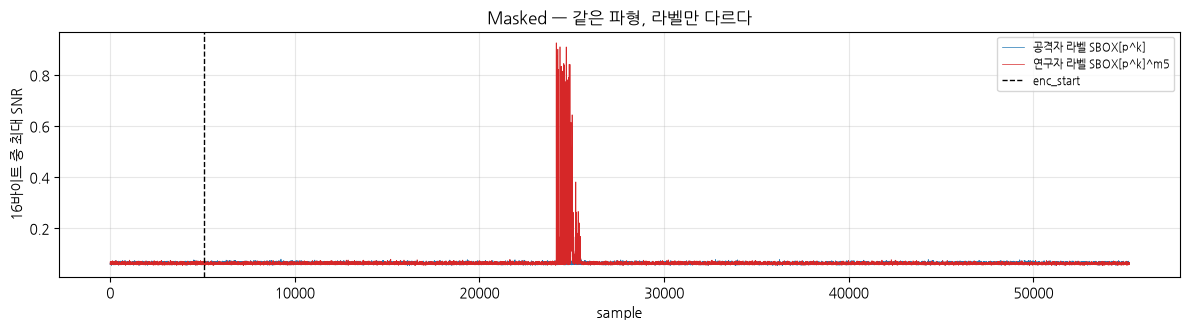

In [12]:
if tid in data and data[tid]["m"] is not None:
    d = data[tid]
    t, p, k, m = d["t"], d["p"], d["k"], d["m"]
    lo = enc_start[tid]

    v_att = snr_of(t, sbox_out(p, k))
    v_res = snr_of(t, np.bitwise_xor(sbox_out(p, k), m[:, 5:6]))

    fig, ax = plt.subplots(figsize=(12, 3.4))
    ax.plot(v_att.max(axis=0), lw=0.5, color="C0",
            label="공격자 라벨 SBOX[p^k]")
    ax.plot(v_res.max(axis=0), lw=0.5, color="C3",
            label="연구자 라벨 SBOX[p^k]^m5")
    ax.axvline(lo, color="k", ls="--", lw=1.0, label="enc_start")
    ax.set_title("Masked — 같은 파형, 라벨만 다르다")
    ax.set_xlabel("sample"); ax.set_ylabel("16바이트 중 최대 SNR")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()

---
## 11. 마스크 품질 점검

10절의 결론은 마스킹 난수의 **품질**에 기대고 있다. 마스크가 매번 새로 뽑히고 8비트를
균일하게 덮어야 방어가 성립한다. 그러니 분석에 쓰기 전에 데이터 자체를 확인한다.

| 확인 | 왜 |
|---|---|
| Subset 마다 마스크가 전부 고유한가 | 같은 값이 반복되면 난수원이 어딘가에서 되감겼다는 뜻이다 |
| 난수부 `mask[0..5]` 가 0–255 를 덮는가 | 한쪽 끝이 비면 마스크가 균일하지 않고, 그만큼 1차 누설이 남는다 |

`mask[6..9]` 는 `mask[0..3]` 에서 유도한 값이라 별도 판정 대상이 아니다.

In [13]:
import h5py

if tid in data:
    path = require_target(tid)["dataset"]
    with h5py.File(path, "r") as h5:
        print("%-12s %8s %10s  %s" % ("Subset", "장수", "고유 마스크", "판정"))
        for g in h5:
            if "mask" not in h5[g]:
                continue
            mm = h5[g]["mask"][:]
            uniq = np.unique(mm, axis=0).shape[0]
            print("/%-11s %8d %10d  %s" % (
                g, mm.shape[0], uniq,
                "OK" if uniq == mm.shape[0] else "!! 중복 %d" % (mm.shape[0] - uniq)))

        mm = h5["explore"]["mask"][:]
        print()
        print("mask[0..5] (난수) 관측 범위 : %d ~ %d" % (mm[:, :6].min(), mm[:, :6].max()))
        print("mask[6..9] (유도) 관측 범위 : %d ~ %d" % (mm[:, 6:].min(), mm[:, 6:].max()))
        print("→ 난수부가 0~255 를 덮고 중복이 없으면 10절의 전제가 성립한다.")

Subset             장수     고유 마스크  판정
/attack         10000      10000  OK
/explore         5000       5000  OK
/profiling     100000     100000  OK
/tvla_fk         1000       1000  OK
/tvla_rk         1000       1000  OK

mask[0..5] (난수) 관측 범위 : 0 ~ 255
mask[6..9] (유도) 관측 범위 : 0 ~ 255
→ 난수부가 0~255 를 덮고 중복이 없으면 10절의 전제가 성립한다.


---
## 12. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 시점별 신호대잡음비로 **누설 위치**를 찾는다 (키 복구 아님) |
| API | `SNR(nc)` → `fit_u(traces, x)` → `get_snr()` |
| `traces` | `(n, ns)` `int16` |
| `x` | `(n, nv)` `uint16` — **2차원**. `Ttest` 와 다르다 |
| 결과 | `(nv, ns)` — 변수마다 한 줄 |
| 판단 기준 | 무작위 라벨로 잰 **잡음 바닥**과 비교한다 |
| 산출물 | `nb_output/poi_{tiny-AES-c,masked-aes-c}.npz` — `poi`, `poi_windows`, `enc_start` |

### 이 노트북이 이후 노트북에 넘기는 것

- **`enc_start`** — 비교는 암호화 구간에서 한다. 키 스케줄은 두 타겟 모두 비마스킹이라
  포함하면 마스킹 효과가 가려진다.
- **POI** — 암호화 구간 안에서 고른 값. 3.0 CPA, 4.x 프로파일링이 이 창만 읽는다.
- **관점 분리** — 공격자 셀은 `mask` 를 쓰지 않는다. 연구자 절만 쓴다.

### 실패 시 점검

1. `ValueError: The classes array has N dimensions` → 라벨을 `(n, nv)` 로 만든다.
2. SNR 이 전 구간에서 바닥과 구분되지 않는다 → 트레이스를 늘리거나, 라벨(중간값) 정의가
   타겟 구현과 맞는지 본다. Masked 에서 이렇게 나오는 것은 **정상**이며 곧 마스킹의 효과다.
3. 결과에 `NaN` 이 많다 → 표본이 없는 클래스가 있다는 뜻. 장수를 늘린다.
4. `enc_start` 가 0 이나 파형 끝에 붙는다 → 평문 라벨 SNR 이 제대로 잡히지 않은 것이다.
   트리거 구간에 암호화가 실제로 들어 있는지(수집 노트북의 `trig_count`)부터 확인한다.

다음: `1.1.Quantizer.ipynb` — SCALib 이 요구하는 `int16` 로 파형을 옮기는 방법.